# 딥러닝 입문 — overview
# 인공지능수학에서 무엇이 달라지는가, 그리고 이 수업을 마치면 무엇을 할 수 있는가

---

> **이 노트북의 목적**  
> 본격적인 수업 전에 전체 그림을 먼저 보는 시간입니다.  
> 코드를 완전히 이해하지 않아도 됩니다. 결과를 보고 느끼는 것이 목표입니다.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)


---
# Part 1. 🔁 인공지능수학에서 무엇이 달라지는가

인공지능수학에서 배운 것을 한 문장으로 요약하면:

> **"뉴런 하나가 어떻게 학습하는가"** — 수학 원리 이해

딥러닝 수업은 그 뉴런을 **수백, 수천 개 쌓으면 무슨 일이 일어나는가**를 다룹니다.

## 두 수업의 차이

| | 인공지능수학 | 딥러닝 입문 |
|---|---|---|
| **모델** | 뉴런 1개 | 뉴런 수백~수천 개를 층층이 쌓음 |
| **결정경계** | 직선 (선형) | 복잡한 곡선 (비선형) |
| **데이터** | 단순한 수치 | 이미지, 텍스트, 음성 |
| **gradient 계산** | 손으로 수식 유도 | PyTorch가 자동으로 계산 |
| **도구** | NumPy | PyTorch |
| **목표** | 수학 원리 이해 | 실제 문제 구현 |

---

## 같은 데이터, 같은 문제 — 왜 결과가 이렇게 다른가

인공지능수학에서 본 달 모양 데이터입니다.  
뉴런 하나(로지스틱 회귀)와 뉴런을 쌓은 모델(신경망)을 비교해보세요.


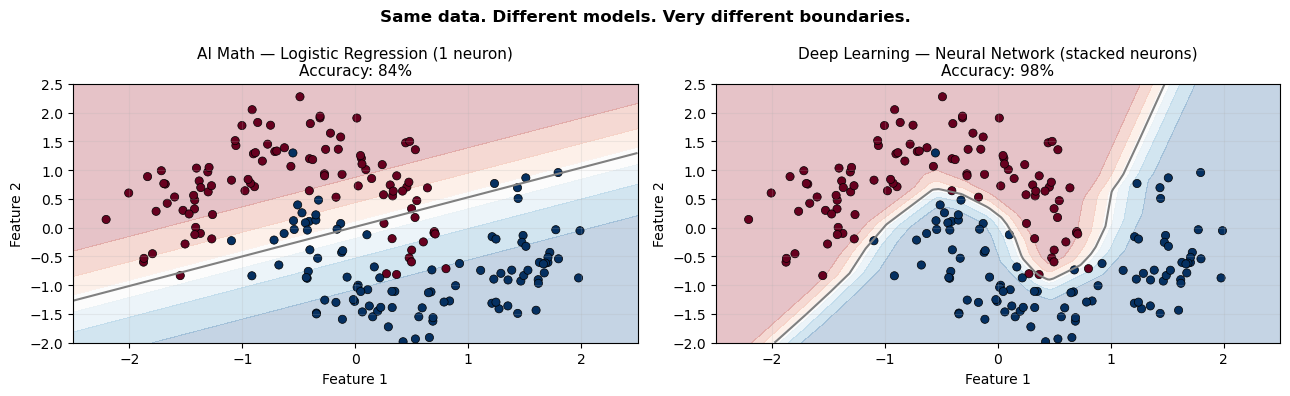

AI Math model  (1 neuron)       accuracy: 84%
Deep Learning  (stacked neurons) accuracy: 98%


In [3]:
# Same moon dataset — logistic regression (AI Math) vs neural network (Deep Learning)
X_moon, y_moon = make_moons(n_samples=200, noise=0.2, random_state=42)
sc = StandardScaler()
X_moon_s = sc.fit_transform(X_moon)

# AI Math model: single neuron
lr_model  = LogisticRegression().fit(X_moon_s, y_moon)
# Deep Learning model: stacked neurons
mlp_model = MLPClassifier(hidden_layer_sizes=(20, 20),
                           max_iter=3000, random_state=42).fit(X_moon_s, y_moon)

xx, yy = np.meshgrid(np.linspace(-2.5, 2.5, 300),
                      np.linspace(-2.0, 2.5, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

Z_lr  = lr_model.predict_proba(grid)[:,1].reshape(xx.shape)
Z_mlp = mlp_model.predict_proba(grid)[:,1].reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, Z, title, acc in [
    (axes[0], Z_lr,  'AI Math — Logistic Regression (1 neuron)', lr_model.score(X_moon_s, y_moon)),
    (axes[1], Z_mlp, 'Deep Learning — Neural Network (stacked neurons)',   mlp_model.score(X_moon_s, y_moon))
]:
    ax.contourf(xx, yy, Z, alpha=0.25, cmap='RdBu')
    ax.contour(xx, yy, Z, levels=[0.5], colors='gray', linewidths=1.5)
    ax.scatter(X_moon_s[:,0], X_moon_s[:,1], c=y_moon,
               cmap='RdBu', edgecolors='k', s=35, linewidths=0.5)
    ax.set_title(f'{title}\nAccuracy: {acc*100:.0f}%', fontsize=11)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.grid(True, alpha=0.2)

plt.suptitle('Same data. Different models. Very different boundaries.',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'AI Math model  (1 neuron)       accuracy: {lr_model.score(X_moon_s, y_moon)*100:.0f}%')
print(f'Deep Learning  (stacked neurons) accuracy: {mlp_model.score(X_moon_s, y_moon)*100:.0f}%')


> ❓ 뉴런을 여러 개 쌓으면 왜 곡선 경계를 그릴 수 있을까요?  
> 그리고 뉴런 하나는 왜 직선밖에 못 그릴까요?
>
> 이 질문의 답이 이 수업 전체를 관통합니다.

---
# Part 2. 🧠 뉴런을 쌓으면 무슨 일이 일어나는가

## 2-1. 인공지능수학에서 배운 것: 뉴런 하나

$$z = w_1 x_1 + w_2 x_2 + \cdots + b, \qquad \hat{y} = f(z)$$

$f$만 바꾸면서 선형회귀, 로지스틱회귀, 소프트맥스를 만들었습니다.  
그리고 이 모델의 결정경계는 항상 **직선**이었습니다.

## 2-2. 딥러닝: 뉴런을 층층이 쌓기

뉴런 여러 개를 병렬로 놓은 것이 **층(layer)** 입니다.  
그 층을 여러 개 쌓은 것이 **신경망(Neural Network)** 입니다.

## 2-3. 층이 깊어질수록 결정경계가 복잡해진다

아래 코드를 실행해보세요. 원형으로 섞인 데이터를 뉴런 수에 따라 분류해봅니다.


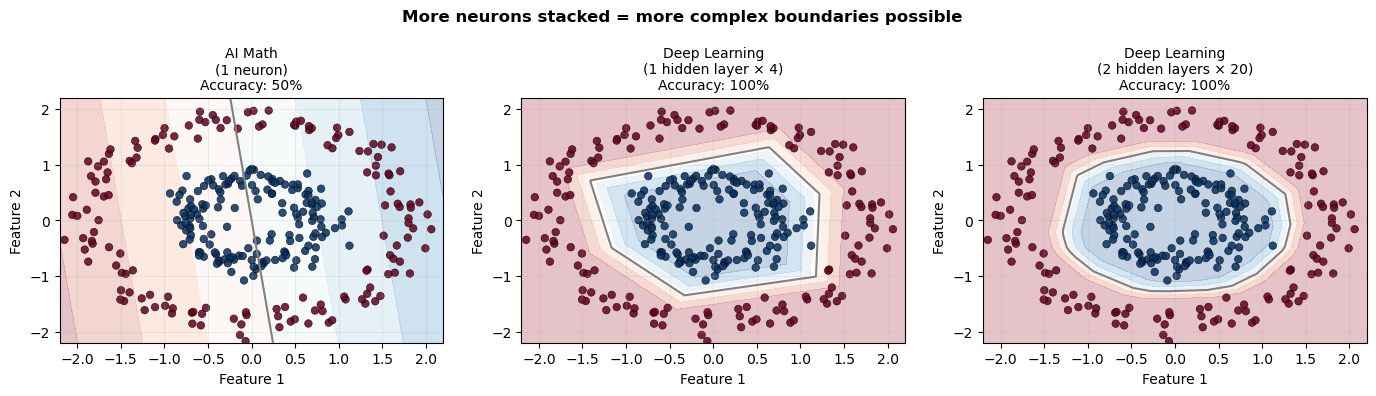

In [4]:
# Concentric circles — impossible to separate with a straight line
X_circ, y_circ = make_circles(n_samples=300, noise=0.08, factor=0.4, random_state=42)
X_s = StandardScaler().fit_transform(X_circ)

xx, yy = np.meshgrid(np.linspace(-2.2, 2.2, 300),
                      np.linspace(-2.2, 2.2, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

configs = [
    ('AI Math\n(1 neuron)',              LogisticRegression()),
    ('Deep Learning\n(1 hidden layer × 4)',   MLPClassifier((4,),     max_iter=5000, random_state=42)),
    ('Deep Learning\n(2 hidden layers × 20)', MLPClassifier((20, 20), max_iter=5000, random_state=42)),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (title, model) in zip(axes, configs):
    model.fit(X_s, y_circ)
    Z   = model.predict_proba(grid)[:,1].reshape(xx.shape)
    acc = model.score(X_s, y_circ)

    ax.contourf(xx, yy, Z, alpha=0.25, cmap='RdBu')
    ax.contour(xx, yy, Z, levels=[0.5], colors='gray', linewidths=1.5)
    ax.scatter(X_s[:,0], X_s[:,1], c=y_circ,
               cmap='RdBu', edgecolors='k', s=30, linewidths=0.4, alpha=0.85)
    ax.set_title(f'{title}\nAccuracy: {acc*100:.0f}%', fontsize=10)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.grid(True, alpha=0.2)

plt.suptitle('More neurons stacked = more complex boundaries possible',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


---
# Part 3. 🔧 도구가 달라진다 — NumPy → PyTorch

## 3-1. 인공지능수학: gradient를 손으로 계산했다

인공지능수학에서 우리는 gradient를 수식으로 직접 유도하고 코드로 구현했습니다.

```python
# 인공지능수학 — 매번 직접 수식을 써야 했다
dw = (2/N) * X.T @ (y_pred - y)   # MSE gradient
db = 2 * np.mean(y_pred - y)
w  = w - lr * dw
b  = b - lr * db
```

뉴런이 1개일 때는 이것으로 충분합니다.  
하지만 뉴런이 수천 개이고 층이 수십 개라면, gradient 수식을 손으로 유도하는 것은 불가능합니다.

## 3-2. 딥러닝: PyTorch가 자동으로 계산한다

```python
# 딥러닝 — 모델이 아무리 복잡해도 항상 이 다섯 줄
optimizer.zero_grad()        # gradient 초기화
y_pred = model(X)            # forward pass
loss   = criterion(y_pred, y)
loss.backward()              # gradient 자동 계산  ← 수식 불필요
optimizer.step()             # 파라미터 자동 업데이트
```

수식을 몰라도 된다는 뜻이 아닙니다.  
**인공지능수학에서 배운 원리를 알기 때문에**, `loss.backward()` 한 줄이 무엇을 하는지 이해할 수 있습니다.  
그것이 인공지능수학을 먼저 배운 이유입니다.

## 3-3. 코드 비교


In [5]:
# AI Math (NumPy) vs Deep Learning (PyTorch) — side-by-side comparison
print('=' * 64)
print('  AI Math (NumPy)               Deep Learning (PyTorch)')
print('=' * 64)

rows = [
    ('Model',    'w = np.zeros((2,1))',          'model = nn.Linear(2, 1)'),
    ('Forward',  'y_pred = X @ w + b',            'y_pred = model(X)'),
    ('Loss',     'loss = np.mean((y_pred-y)**2)', 'loss = criterion(y_pred, y)'),
    ('Gradient', 'dw = (2/N) * X.T @ diff',      'loss.backward()   # auto'),
    ('Update',   'w = w - lr * dw',               'optimizer.step()  # auto'),
]

for step, numpy_code, torch_code in rows:
    print(f'\n  [{step}]')
    print(f'    NumPy  : {numpy_code}')
    print(f'    PyTorch: {torch_code}')

print()
print('-' * 64)
print('  The structure is identical.')
print('  Only the gradient computation is automated.')
print('-' * 64)


  AI Math (NumPy)               Deep Learning (PyTorch)

  [Model]
    NumPy  : w = np.zeros((2,1))
    PyTorch: model = nn.Linear(2, 1)

  [Forward]
    NumPy  : y_pred = X @ w + b
    PyTorch: y_pred = model(X)

  [Loss]
    NumPy  : loss = np.mean((y_pred-y)**2)
    PyTorch: loss = criterion(y_pred, y)

  [Gradient]
    NumPy  : dw = (2/N) * X.T @ diff
    PyTorch: loss.backward()   # auto

  [Update]
    NumPy  : w = w - lr * dw
    PyTorch: optimizer.step()  # auto

----------------------------------------------------------------
  The structure is identical.
  Only the gradient computation is automated.
----------------------------------------------------------------


---
# Part 4. 이 수업의 포지션

## 4-1. 인공지능수학에서 배운 원리가 그대로 확장된다

인공지능수학 수업의 전략을 기억하시나요?

$$\text{복잡한 문제} \xrightarrow{\text{핵심 수학은 같다}} \text{매우 단순한 문제로 수학 이해}$$

딥러닝 수업의 전략도 같습니다:

$$\text{뉴런 1개} \xrightarrow{\text{같은 원리, 더 많이}} \text{뉴런 수천 개 → 이미지·텍스트 처리}$$

## 4-2. 이 수업에서 다루는 모델들

이 수업에서 배우는 모델들은 모두 **인공뉴런을 어떻게 쌓느냐**의 차이입니다.


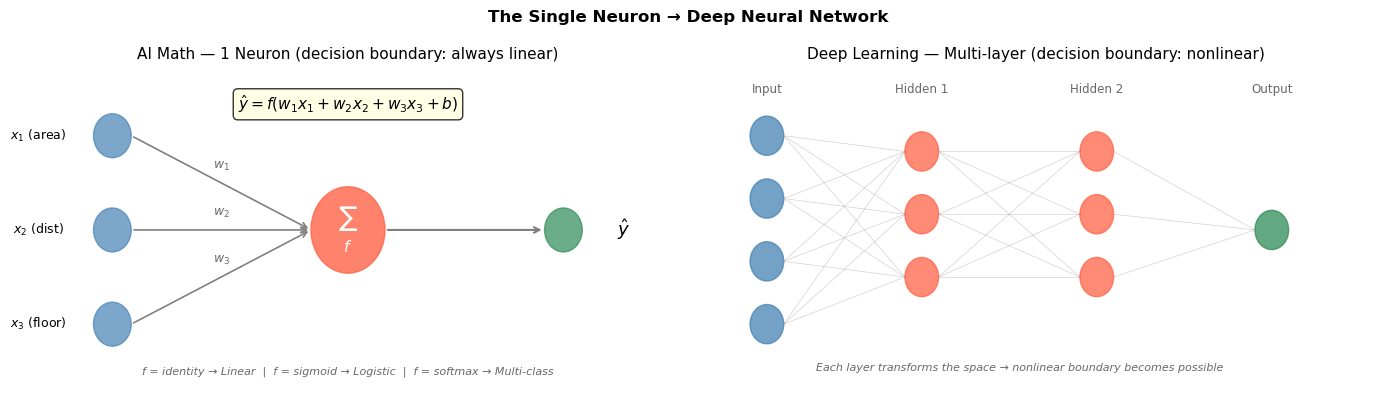

In [6]:
# AI Math (single neuron) → Deep Learning (multi-layer) structure
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Left: AI Math — single neuron ──────────────────────
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 4); ax.axis('off')

inputs = [(1.5, 3.2), (1.5, 2.0), (1.5, 0.8)]
labels = ['$x_1$ (area)', '$x_2$ (dist)', '$x_3$ (floor)']
for (x, y), label in zip(inputs, labels):
    ax.add_patch(plt.Circle((x, y), 0.28, color='steelblue', alpha=0.7))
    ax.text(x - 1.1, y, label, ha='center', va='center', fontsize=9)

ax.add_patch(plt.Circle((5.0, 2.0), 0.55, color='tomato', alpha=0.8))
ax.text(5.0, 2.15, '$\\sum$', ha='center', va='center', fontsize=14, color='white')
ax.text(5.0, 1.78, '$f$',    ha='center', va='center', fontsize=11, color='white')
ax.add_patch(plt.Circle((8.2, 2.0), 0.28, color='seagreen', alpha=0.7))
ax.text(9.1, 2.0, '$\\hat{y}$', ha='center', va='center', fontsize=13)

weights = ['$w_1$', '$w_2$', '$w_3$']
for (x, y), wlabel in zip(inputs, weights):
    ax.annotate('', xy=(4.45, 2.0), xytext=(x+0.28, y),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.2))
    mid_x = (x+0.28+4.45)/2
    mid_y = (y+2.0)/2
    ax.text(mid_x, mid_y+0.18, wlabel, ha='center', fontsize=9, color='dimgray')
ax.annotate('', xy=(7.92, 2.0), xytext=(5.55, 2.0),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
ax.text(5.0, 3.6, r'$\hat{y} = f(w_1 x_1 + w_2 x_2 + w_3 x_3 + b)$',
        ha='center', va='center', fontsize=11,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
ax.text(5.0, 0.2,
        'f = identity → Linear  |  f = sigmoid → Logistic  |  f = softmax → Multi-class',
        ha='center', va='center', fontsize=8, color='dimgray', style='italic')
ax.set_title('AI Math — 1 Neuron (decision boundary: always linear)', fontsize=11, pad=10)

# ── Right: Deep Learning — multi-layer ─────────────────
ax2 = axes[1]
ax2.set_xlim(0, 10); ax2.set_ylim(0, 4); ax2.axis('off')

layer_defs = [
    (1.0,  [3.2, 2.4, 1.6, 0.8], 'steelblue', 'Input'),
    (3.3,  [3.0, 2.2, 1.4],      'tomato',    'Hidden 1'),
    (5.9,  [3.0, 2.2, 1.4],      'tomato',    'Hidden 2'),
    (8.5,  [2.0],                 'seagreen',  'Output'),
]

node_pos = []
for lx, ys, color, lname in layer_defs:
    pos = [(lx, y) for y in ys]
    node_pos.append(pos)
    for (nx, ny) in pos:
        ax2.add_patch(plt.Circle((nx, ny), 0.25, color=color, alpha=0.75))
    ax2.text(lx, 3.75, lname, ha='center', fontsize=8.5, color='dimgray')

for i in range(len(node_pos)-1):
    for (x1, y1) in node_pos[i]:
        for (x2, y2) in node_pos[i+1]:
            ax2.plot([x1+0.25, x2-0.25], [y1, y2], color='gray', lw=0.5, alpha=0.35)

ax2.text(4.75, 0.2,
         'Each layer transforms the space → nonlinear boundary becomes possible',
         ha='center', fontsize=8, color='dimgray', style='italic')
ax2.set_title('Deep Learning — Multi-layer (decision boundary: nonlinear)', fontsize=11, pad=10)

plt.suptitle('The Single Neuron → Deep Neural Network', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


이 수업에서 배우는 모델들은 모두 **뉴런을 어떻게 연결하느냐**의 차이입니다.

| 모델 | 구조 | 주요 용도 | 수업 주차 |
|---|---|---|---|
| MLP (다층 신경망) | 뉴런을 층층이 쌓음 | 수치 데이터 분류·회귀 | 4~5주차 |
| CNN | 이미지 특화 연결 구조 | 이미지 분류, 객체 탐지 | 9~10주차 |
| Transformer | Attention 메커니즘 | 텍스트, 이미지, 음성 | 11주차 |

---
# Part 5. 이 수업을 마치면 — 무엇을 할 수 있나

## 5-1. 실제 이미지를 분류하는 모델을 만들 수 있다 (9~10주차)

CIFAR-10: 비행기, 자동차, 새, 고양이 등 10가지 사물 사진 데이터셋.  
**CNN**으로 직접 학습하고, 이미 학습된 모델을 내 데이터에 적용(**Transfer Learning**)합니다.

## 5-2. ChatGPT의 기반 구조를 이해할 수 있다 (11주차)

ChatGPT, Claude, GPT-4는 모두 **Transformer** 구조입니다.  
이 수업에서 Transformer의 핵심인 **Attention** 이 어떻게 동작하는지 직접 확인합니다.


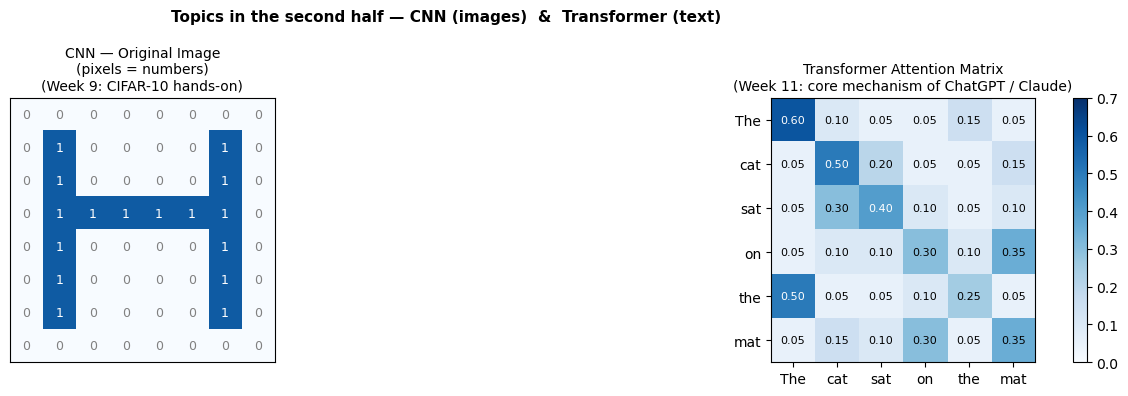

In [7]:
# Two topics covered in the second half of the course
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Left: CNN — how images become numbers ───────────────
ax = axes[0]

# 8×8 simple image (letter H shape)
img = np.array([
    [0,0,0,0,0,0,0,0],
    [0,1,0,0,0,0,1,0],
    [0,1,0,0,0,0,1,0],
    [0,1,1,1,1,1,1,0],
    [0,1,0,0,0,0,1,0],
    [0,1,0,0,0,0,1,0],
    [0,1,0,0,0,0,1,0],
    [0,0,0,0,0,0,0,0],
], dtype=float)

# Edge-detection kernel (core idea of Convolution)
kernel = np.array([[-1,-1,-1],[-1,8,-1],[-1,-1,-1]], dtype=float)
from numpy.lib.stride_tricks import sliding_window_view
feature_map = np.clip((sliding_window_view(img,(3,3)) * kernel).sum(axis=(-1,-2)), 0, None)

for i, (data, title, cmap) in enumerate([
    (img,         'Original Image\n(pixels = numbers)', 'Blues'),
    (feature_map, 'After Convolution\n(edges extracted)', 'Oranges')
]):
    ax_sub = axes[0] if i == 0 else axes[1]
    if i == 0:
        im0 = ax_sub.imshow(data, cmap=cmap, vmin=0, vmax=1.2)
        for r in range(8):
            for c in range(8):
                ax_sub.text(c, r, f'{data[r,c]:.0f}', ha='center', va='center',
                            fontsize=9, color='white' if data[r,c]>0.5 else 'gray')
        ax_sub.set_xticks([]); ax_sub.set_yticks([])
        ax_sub.set_title(f'CNN — {title}\n(Week 9: CIFAR-10 hands-on)', fontsize=10)

# ── Right: Transformer Attention ────────────────────────
ax2 = axes[1]
tokens = ['The', 'cat', 'sat', 'on', 'the', 'mat']
attn = np.array([
    [0.60,0.10,0.05,0.05,0.15,0.05],
    [0.05,0.50,0.20,0.05,0.05,0.15],
    [0.05,0.30,0.40,0.10,0.05,0.10],
    [0.05,0.10,0.10,0.30,0.10,0.35],
    [0.50,0.05,0.05,0.10,0.25,0.05],
    [0.05,0.15,0.10,0.30,0.05,0.35],
])
im = ax2.imshow(attn, cmap='Blues', vmin=0, vmax=0.7)
ax2.set_xticks(range(len(tokens))); ax2.set_xticklabels(tokens, fontsize=10)
ax2.set_yticks(range(len(tokens))); ax2.set_yticklabels(tokens, fontsize=10)
for i in range(len(tokens)):
    for j in range(len(tokens)):
        ax2.text(j, i, f'{attn[i,j]:.2f}', ha='center', va='center',
                 fontsize=8, color='white' if attn[i,j]>0.35 else 'black')
plt.colorbar(im, ax=ax2, fraction=0.04)
ax2.set_title('Transformer Attention Matrix\n(Week 11: core mechanism of ChatGPT / Claude)', fontsize=10)

plt.suptitle('Topics in the second half — CNN (images)  &  Transformer (text)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


---
# Part 6. 이 수업에서 배우는 내용 — 미리보기

| 주차 | 주제 | 인공지능수학과의 연결 |
|:---:|---|---|
| 1~2 | NumPy 복습 + 선형·로지스틱 회귀 | 인공지능수학 내용을 코드로 재확인 |
| 3 | PyTorch 입문 | 손 계산 gradient → `loss.backward()` 한 줄 |
| 4~5 | MLP (다층 신경망) | 뉴런 1개 → 여러 층으로 쌓기 |
| 6~7 | 정규화, 최적화 (Adam) | 경사하강법의 실전 심화 |
| 8 | 중간고사 | |
| 9~10 | CNN + Transfer Learning | 이미지 특화 구조, 사전학습 모델 활용 |
| 11 | Transformer 소개 | ChatGPT의 기반 — Attention 직접 확인 |
| 12~15 | 팀 프로젝트 | End-to-end 구현 & 발표 |

---
# 💭 생각해볼 질문

1. 인공지능수학에서 배운 경사하강법이 딥러닝에서도 쓰인다면, 뉴런이 수천 개일 때는 어떻게 gradient를 계산할까요?
2. 이미지는 어떻게 숫자로 표현될까요? (힌트: 픽셀, RGB 채널)
3. `loss.backward()`가 하는 일은 인공지능수학의 어떤 개념과 연결될까요?

---
# 🤖 LLM 파트너 활용 — 오버뷰 버전

오늘 본 내용 중 궁금한 것을 LLM에게 물어보세요. 예시:

```
인공지능수학에서 배운 로지스틱 회귀와
딥러닝의 다층 신경망(MLP)의 차이를 설명해줘.
수학적으로 무엇이 달라지는지 포함해서.
```

```
PyTorch의 loss.backward()가 내부적으로 어떻게 gradient를 계산하는지 설명해줘.
인공지능수학에서 배운 chain rule과 연결해서 설명해줘.
```

```
CNN이 일반 MLP보다 이미지 분류에 왜 좋은지
직관적으로 설명해줘. 파라미터 수 관점에서도 비교해줘.
```

---
# ➡️ 다음 주 예고

**1주차: NumPy 복습 + 선형회귀**

인공지능수학에서 배운 내용을 빠르게 복습합니다.  
shape, 행렬 곱, 경사하강법 — 딥러닝 내내 쓸 기초입니다.  
잊어버렸어도 괜찮습니다. 1~2주차에서 다시 다집니다.
